# HS4002 Week 4

## Task for the day

We'll investigate three relationships:
1. Age and annual income
2. Income and cultural omnivorousness
3. Race and highest education level attained

For each question: (a) visualize, then (b) compute a bivariate statistic.

In [4]:
# !pip install pandas numpy scipy plotnine

import pandas as pd
import numpy as np
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')
from scipy import stats

## Data Preparation

In [5]:
raw_df = pd.read_csv("gss2022_mini.csv")

chosen_variables = [
	"id", "age", "yrlvmus", "yrartxbt", "yrmovie", "yrcreat",
	"income16", "prestg10", "degree", "race"
]
df = raw_df[chosen_variables].dropna().copy()

income_map = {
	1: 500,    2: 2000,   3: 3500,   4: 4500,   5: 5500,   6: 6500,
	7: 7500,   8: 9000,   9: 11250,  10: 13750, 11: 16250, 12: 18750,
	13: 21250, 14: 23750, 15: 27500, 16: 32500, 17: 37500, 18: 45000,
	19: 55000, 20: 67500, 21: 82500, 22: 100000, 23: 120000, 24: 140000,
	25: 160000, 26: 250000
}
df['income_cont'] = df['income16'].map(income_map)

df['binary_lvmus']  = (df['yrlvmus']  == 1).astype(int)
df['binary_artxbt'] = (df['yrartxbt'] == 1).astype(int)
df['binary_movie']  = (df['yrmovie']  == 1).astype(int)
df['binary_creat']  = (df['yrcreat']  == 1).astype(int)
df['omni'] = df[['binary_lvmus','binary_artxbt','binary_movie','binary_creat']].sum(axis=1)

# Investigating the relation between age and annual income

## Calculating covariance

In [6]:
# np.cov returns a 2x2 matrix; [0,1] is the off-diagonal covariance
cov_val = np.cov(df['age'], df['income_cont'])[0, 1]
print(f'Covariance(age, income): {cov_val:.2f}')
np.cov(df['age'], df['income_cont'])

Covariance(age, income): 6961.46


array([[3.01191425e+02, 6.96146150e+03],
       [6.96146150e+03, 5.17655627e+09]])

## Data Visualisation


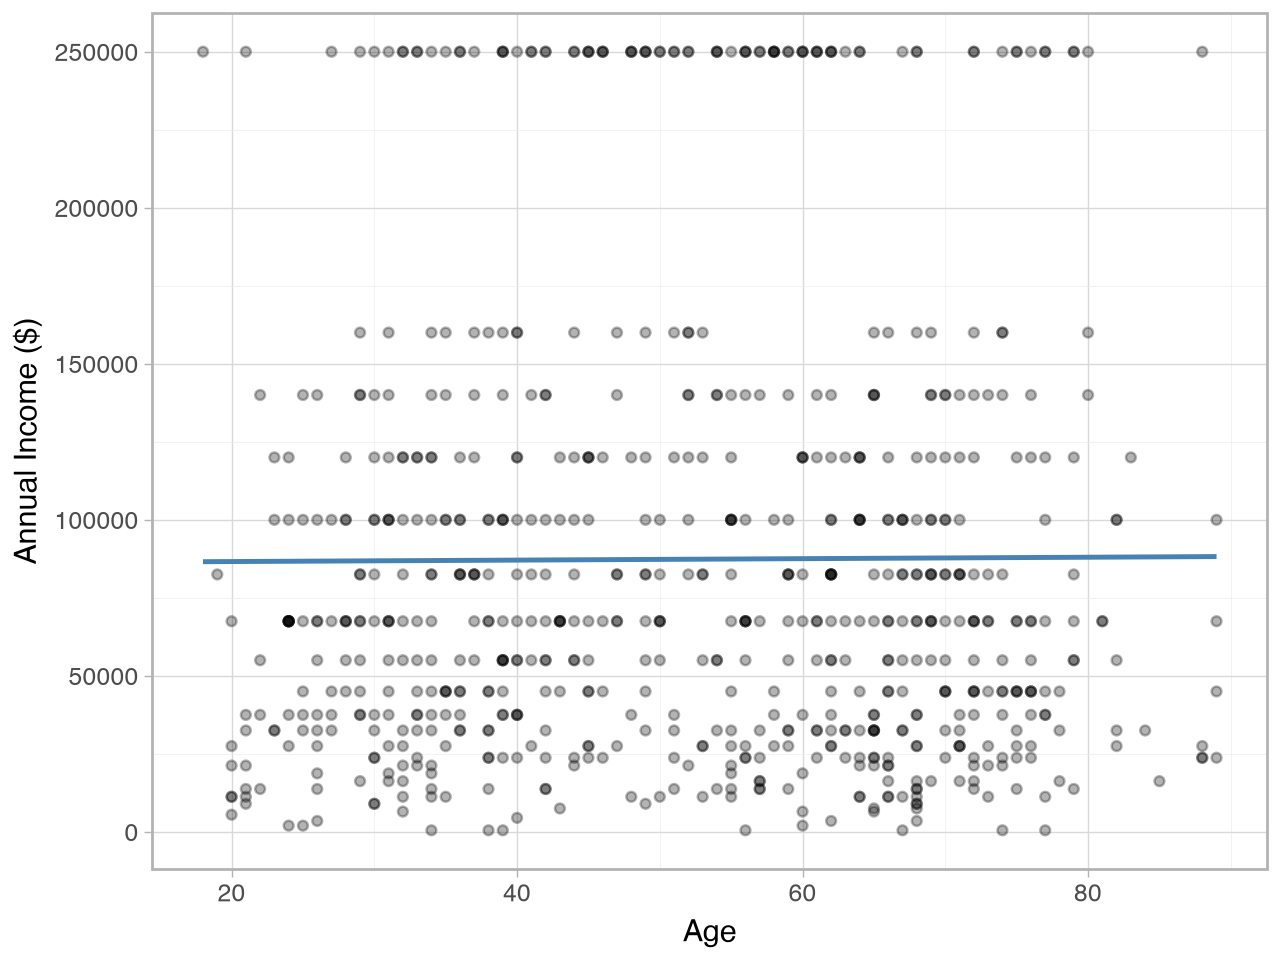

In [7]:
(
	p9.ggplot(df, p9.aes(x='age', y='income_cont')) +
	p9.geom_point(alpha=0.3) +
	p9.geom_smooth(method='lm', se=False, color='steelblue') +
	p9.theme_light() +
	p9.labs(x='Age', y='Annual Income ($)')
)

## Bivariate statistic

Pearson correlation — appropriate for two continuous variables. Comment on the magnitude, direction, and p-value.

In [8]:
r, p = stats.pearsonr(df['age'], df['income_cont'])
print(f'Pearson r = {r:.4f}, p-value = {p:.4f}')

Pearson r = 0.0056, p-value = 0.8822


# Investigating income and cultural omnivorousness

## Data Visualisation

Omnivorousness is ordinal (0–4), so a boxplot is appropriate.

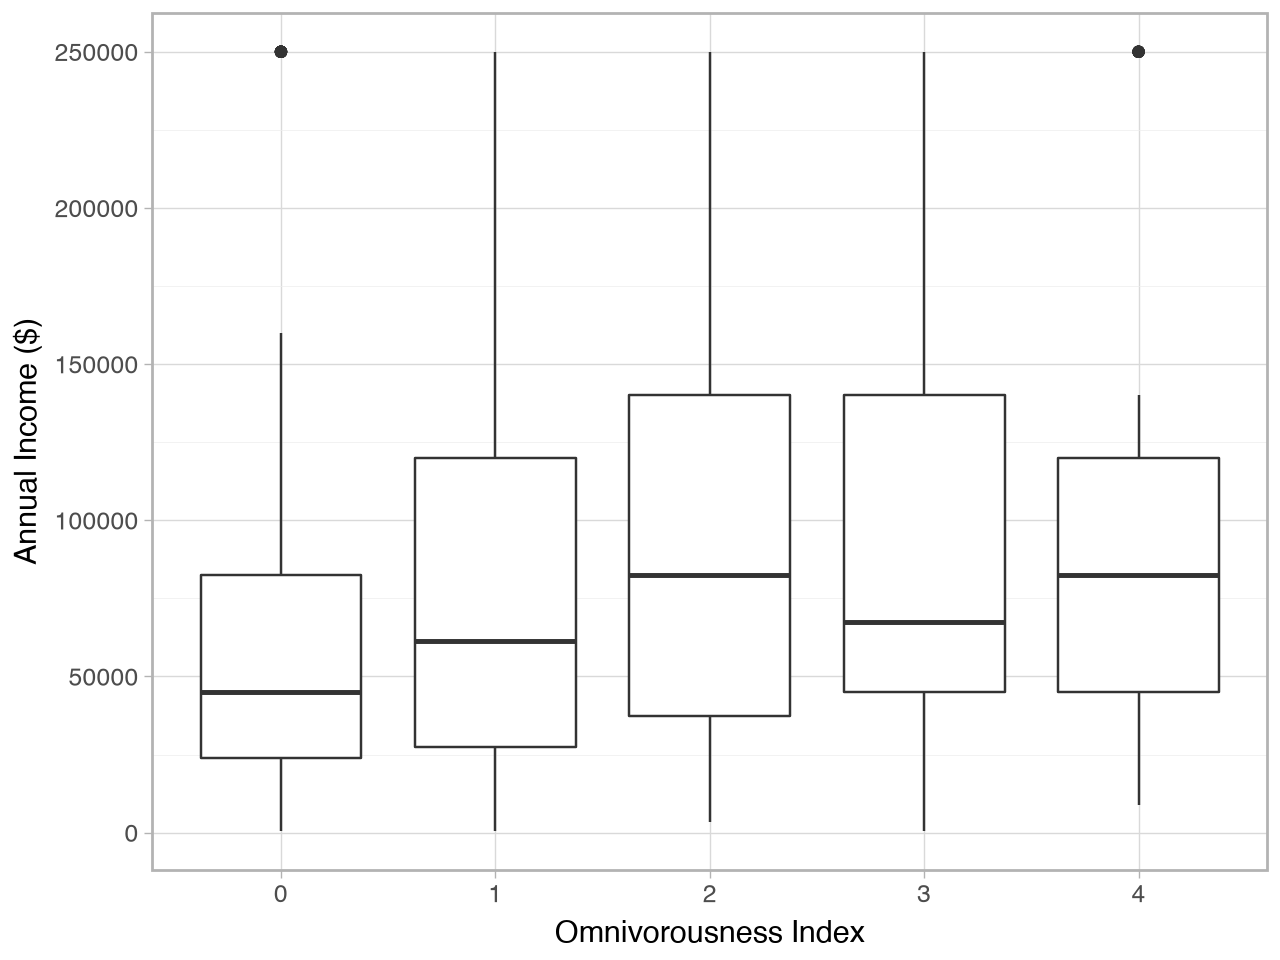

In [9]:
(
	p9.ggplot(df, p9.aes(x='factor(omni)', y='income_cont')) +
	p9.geom_boxplot() +
	p9.theme_light() +
	p9.labs(x='Omnivorousness Index', y='Annual Income ($)')
)

## Bivariate statistic

Spearman correlation — appropriate when one variable is ordinal.

In [10]:
rho, p = stats.spearmanr(df['omni'], df['income_cont'])
print(f'Spearman rho = {rho:.4f}, p-value = {p:.4f}')

Spearman rho = 0.2072, p-value = 0.0000


# Investigating race and highest education level attained

## Recoding variables

In [11]:
df['race_recoded']   = df['race'].map({1: 'White', 2: 'Black'}).fillna('Other')
df['degree_recoded'] = df['degree'].map({
	0: '1:<HS', 1: '2:HS', 2: '3:Assoc.', 3: '4:BA', 4: '5:Grad.'
})

## Preliminary visualisation

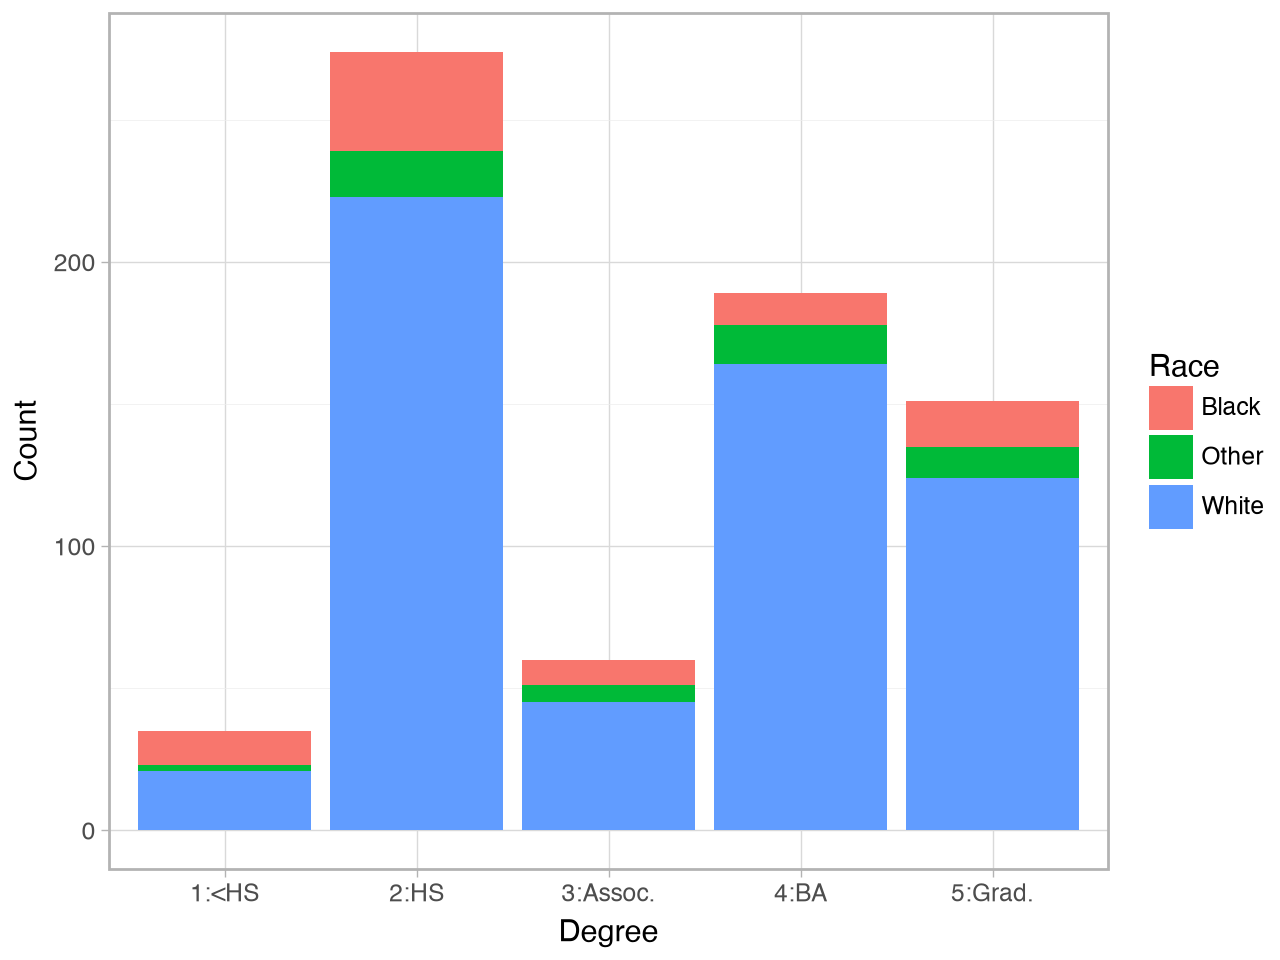

In [12]:
(
	p9.ggplot(df) +
	p9.geom_bar(p9.aes(x='degree_recoded', fill='race_recoded')) +
	p9.theme_light() +
	p9.labs(x='Degree', y='Count', fill='Race')
)

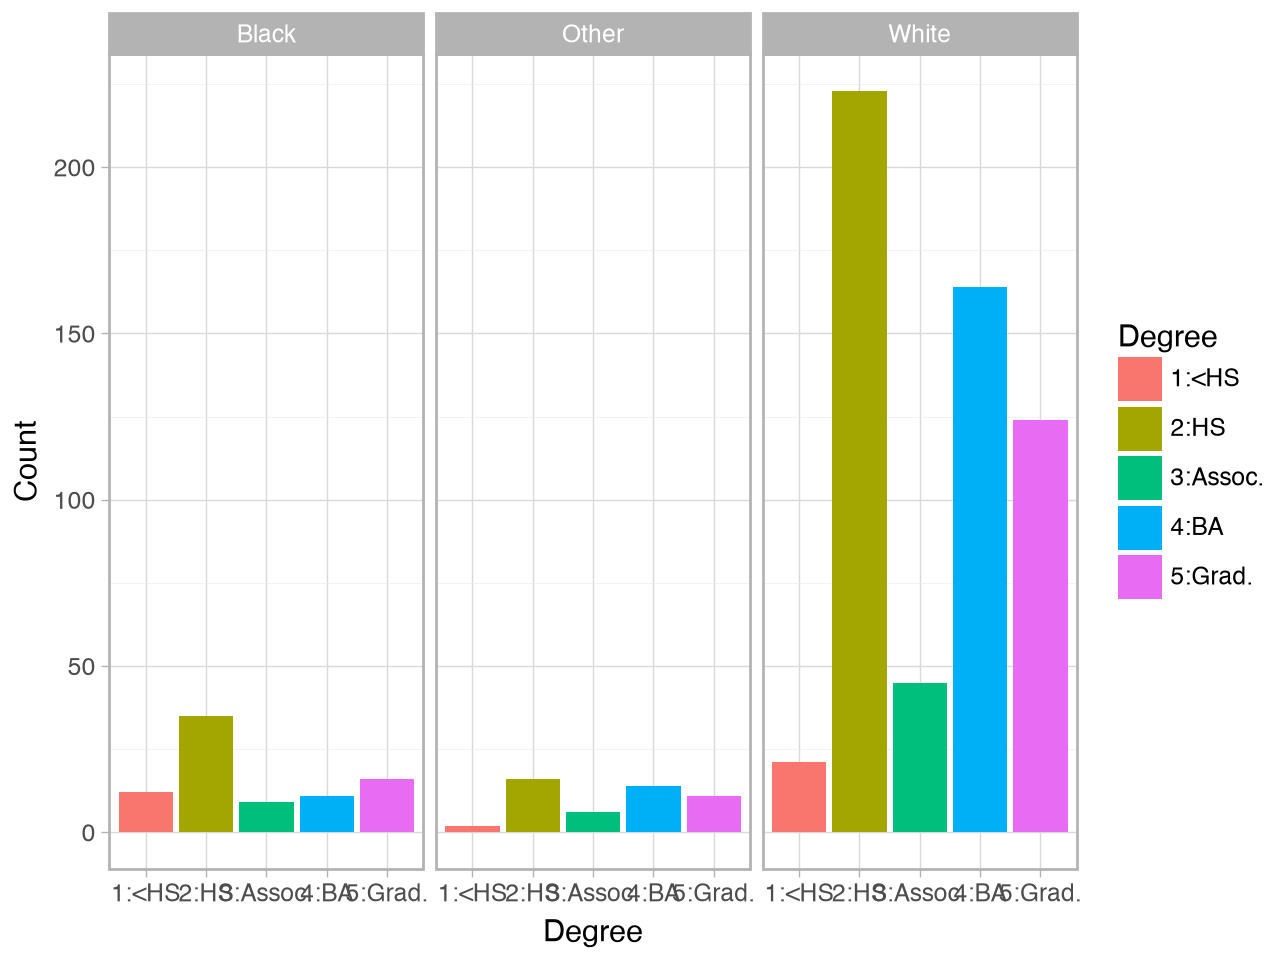

In [13]:
(
	p9.ggplot(df) +
	p9.geom_bar(p9.aes(x='degree_recoded', fill='degree_recoded')) +
	p9.facet_wrap('race_recoded') +
	p9.theme_light() +
	p9.labs(x='Degree', y='Count', fill='Degree')
)

## Bivariate statistic: Chi-square and Cramér's V

Chi-square tests if there is a statistically significant association. Cramér's V measures the strength of that association (0 = no association, 1 = perfect).

In [16]:
contingency = pd.crosstab(df['race_recoded'], df['degree_recoded'])

chi2_result = stats.chi2_contingency(contingency)
cramerv_result = stats.contingency.association(contingency, method='cramer')
cramerv_result

0.13599032806668457

In [17]:
print(chi2_result.pvalue)

0.00096163894136679
